# Simulated events selection and summary

In [ ]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DOCS = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(DOCS / 'scripts'))
from mc_selection_report import load_frame, contamination_summary
from selection import add_truth_signal, cutflow, select

MC_FILE = # Update to actual file

Update MC_FILE if your simulated ROOT file has a different name.


In [10]:
frame = load_frame(MC_FILE)
proton_frame = add_truth_signal(frame, 'proton')
muon_frame = add_truth_signal(frame, 'muon')
proton_flow = cutflow(proton_frame, 'proton')
muon_flow = cutflow(muon_frame, 'muon')
proton_candidates = select(proton_frame, 'proton')
muon_candidates = select(muon_frame, 'muon')
display(proton_flow, muon_flow)

,cut,events,efficiency,purity
0,single_track,120099,0.875293,0.090226
1,pid,10333,0.075308,0.302719
2,fiducial_volume,6158,0.044880,0.379669
3,positive_flash,5608,0.040872,0.404957
4,track_length,5574,0.040624,0.404916
5,forward_z,3884,0.028307,0.444130
6,flash_track_match,3299,0.024043,0.484086
7,charge_flash_match,1574,0.011471,0.557179


,cut,events,efficiency,purity
0,single_track,120099,0.875293,0.139651
1,pid,104467,0.761366,0.152862
2,fiducial_volume,18194,0.132600,0.173574
3,positive_flash,14973,0.109125,0.195018
4,track_length,14286,0.104118,0.177446
5,forward_z,6779,0.049406,0.216109
6,flash_track_match,4141,0.030180,0.292924
7,charge_flash_match,2072,0.015101,0.370174
8,ng2hip_r1cm,1764,0.012856,0.384921
9,ng2hip_r3cm,1454,0.010597,0.442916


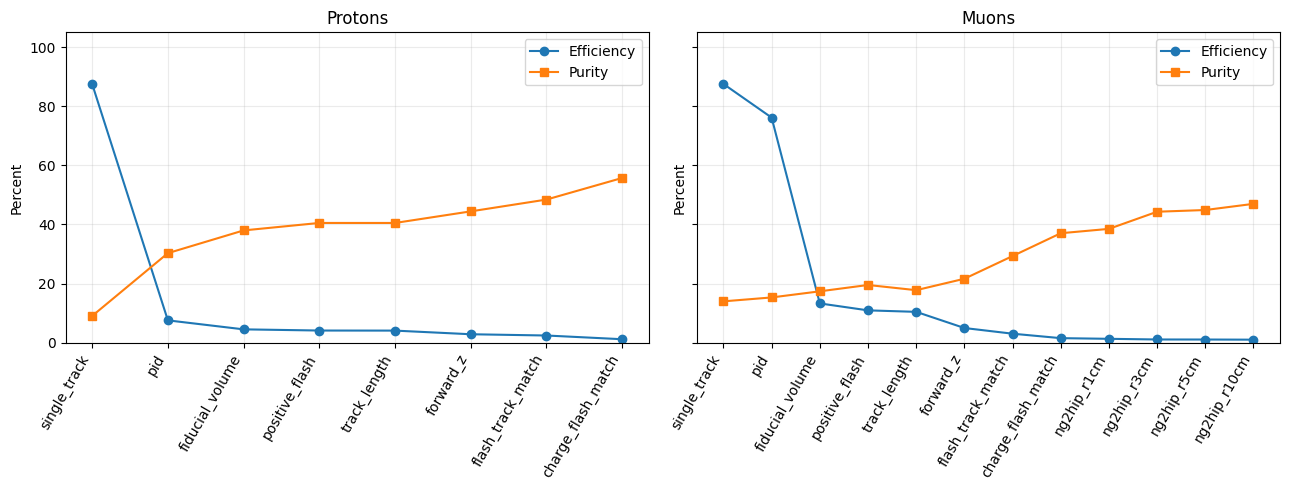

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, flow, title in [
    (axes[0], proton_flow, 'Protons'),
    (axes[1], muon_flow, 'Muons'),
]:
    positions = np.arange(len(flow))
    ax.plot(positions, flow['efficiency'] * 100, 'o-', label='Efficiency')
    if 'purity' in flow:
        ax.plot(positions, flow['purity'] * 100, 's-', label='Purity')
    ax.set_xticks(positions)
    ax.set_xticklabels(flow['cut'], rotation=60, ha='right')
    ax.set_ylim(0, 105)
    ax.set_ylabel('Percent')
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend()

plt.tight_layout()
plt.show()

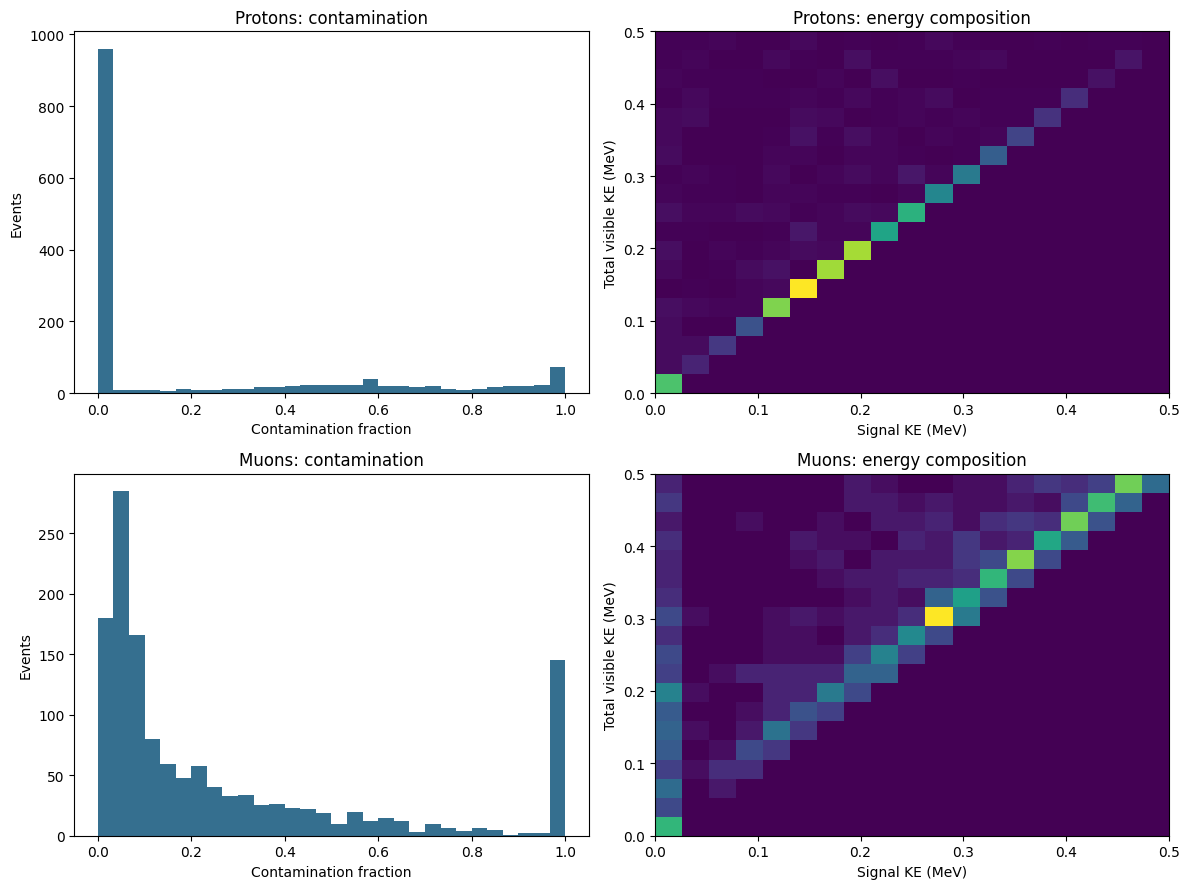

In [18]:
proton_contamination = contamination_summary(frame, proton_candidates, 'proton')
muon_contamination = contamination_summary(frame, muon_candidates, 'muon')

bins2d = np.linspace(0, 0.5, 20), np.linspace(0, 0.5, 20)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for row, (table, title) in enumerate([
    (proton_contamination, 'Protons'),
    (muon_contamination, 'Muons'),
]):
    axes[row, 0].hist(table['contamination_fraction'].dropna(), bins=30, range=(0, 1), color='#356f8f')
    axes[row, 0].set(xlabel='Contamination fraction', ylabel='Events', title=f'{title}: contamination')
    axes[row, 1].hist2d(table['signal_ke_mev'], table['total_visible_ke_mev'], bins=bins2d, cmap='viridis')
    axes[row, 1].set(xlabel='Signal KE (MeV)', ylabel='Total visible KE (MeV)', title=f'{title}: energy composition')


plt.tight_layout()
plt.show()

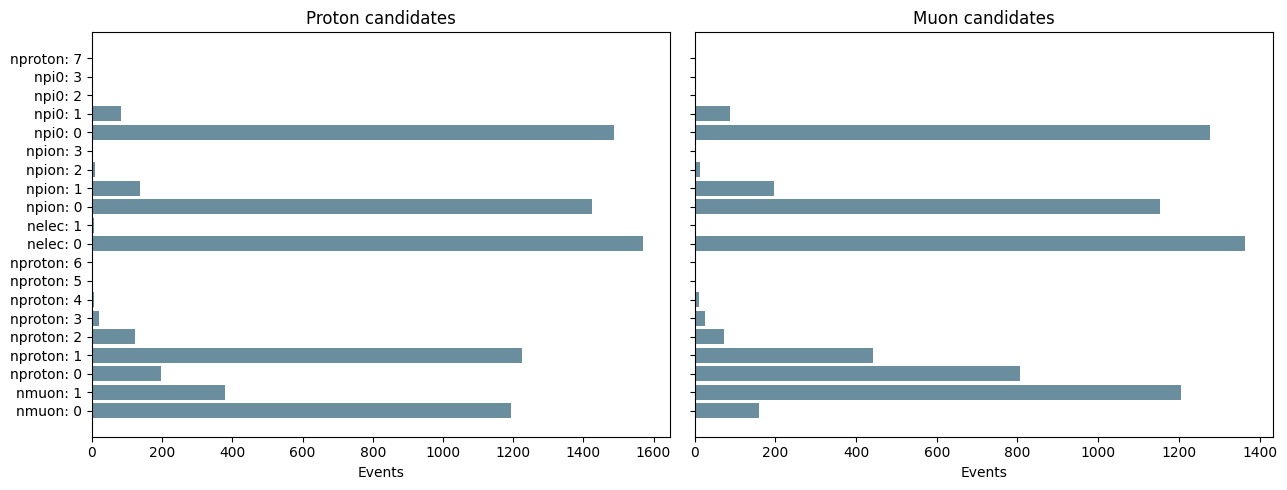

In [13]:
multiplicity_columns = ['nmuon', 'nproton', 'nelec', 'npion', 'npi0']
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, candidates, title in [
    (axes[0], proton_candidates, 'Proton candidates'),
    (axes[1], muon_candidates, 'Muon candidates'),
]:
    counts = [candidates[column].value_counts().sort_index() for column in multiplicity_columns]
    labels = []
    values = []
    for column, series in zip(multiplicity_columns, counts):
        for multiplicity, count in series.items():
            labels.append(f'{column}: {multiplicity}')
            values.append(count)
    ax.barh(labels, values, color='#6b8e9f')
    ax.set_title(title)
    ax.set_xlabel('Events')

plt.tight_layout()
plt.show()